**LAB 4 - Cluster 1**

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))
from utils.io import save_versioned, load_latest, raw_path, get_output_dir

# ============================================================
# CELL 1 – Setup and imports
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import cdist
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer

import skfuzzy as fuzz
from skfuzzy import control as ctrl

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
output_dir = get_output_dir(4)

print('All libraries imported successfully.')
print(f"   → numpy      : {np.__version__}")
print(f"   → pandas     : {pd.__version__}")
print(f"   → skfuzzy    : {fuzz.__version__}")


Output directory: LAB4/outputs/20260617_210805
All libraries imported successfully.
   → numpy      : 2.0.2
   → pandas     : 2.3.3
   → skfuzzy    : 0.5.0


In [2]:
# ─── Configuration ────────────────────────────────────────────────────────────
DS_KEY   = '3a'
SOM_SIZE = '12x12'   # best SOM size as selected by LAB3 (max intra-var criterion)

# Raw dataset (4000×120) keeps all original comorbidity columns
df_full          = pd.read_excel(str(raw_path('Dataset_DAPPC_2026.xlsx')),
                                 sheet_name='Dataset')
assignment_df = load_latest(f'LAB2_assignments_knn_global_{SOM_SIZE}')

print(f'Dataset shape      : {df_full.shape}')
print(f'Assignment shape   : {assignment_df.shape}')


Loading → LAB2/outputs/20260617_210035/LAB2_assignments_knn_global_12x12.xlsx


Dataset shape      : (4000, 120)
Assignment shape   : (3893, 11)


In [3]:
# ============================================================
# CELL 2d – Merge and Cluster 1 selection
# ============================================================

id_cols     = ['subject_id', 'hadm_id', 'stay_id', 'ICU', 'ICU_intime', 'ICU_outtime']
outcome_col = 'outcome'
join_cols   = ['subject_id', 'hadm_id', 'stay_id']

# Feature columns (excludes ID and outcome)
feature_cols = [c for c in df_full.columns if c not in id_cols + [outcome_col]]

# Merge with cluster assignments
df = df_full.merge(
    assignment_df[join_cols + ['cluster_id']],
    on=join_cols,
    how='inner'
)

print(" Merge completato!")
print(f"   → Dataset shape dopo merge : {df.shape}")
print(f"   → Numero feature           : {len(feature_cols)}")
print(f"\n Distribuzione cluster:")
display(df['cluster_id'].value_counts().sort_index())


 Merge completato!
   → Dataset shape dopo merge : (3893, 121)
   → Numero feature           : 113

 Distribuzione cluster:


cluster_id
1       18
2       28
3       51
4       99
5      479
6     1052
7      107
8      110
9      476
10      10
11      17
12      41
13     290
14      79
15      20
16     209
17     116
18      67
19      80
20     164
21     361
22      19
Name: count, dtype: int64

In [4]:
# ============================================================
# CELL 3 – Feature loading from LAB3 + cluster filtering
# ============================================================

# Load ACO-selected features from LAB3 (8 features)
feat_df = load_latest('LAB3_selected_features')
aco_features = feat_df['feature'].tolist()

# ── Random split (seed=42) of the 8 ACO features into the two clusters ──
# Cluster A keeps 6 features. The two features removed from A (and assigned to
# Cluster B) are first_plateau_pressure and std_mean_airway_pressure.
# charlson_comorbidity_index and std_plateau_pressure stay in A but are shared
# with Cluster B to complete its 4 features.
cluster_a_features = [
    'neuromuscular_blockers',
    'coronary_artery_disease',
    'charlson_comorbidity_index',
    'first_lactate',
    'pulmonary_hypertension',
    'std_plateau_pressure',
]

# Keep only Cluster A features (preserve ACO order where available)
selected_features = [f for f in aco_features if f in cluster_a_features]
for f in cluster_a_features:
    if f not in selected_features:
        selected_features.append(f)

print(f'ACO features from LAB3 ({len(aco_features)}): {aco_features}')
print(f'\nCluster A features after seed=42 split ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    print(f'  {i:2d}. {f}')

# ── LAB4 spec: membership functions are built on the COMPLETE dataset ──
# (all subjects, every cluster), not on the single-cluster subset.
# X_full_imputed provides the universes/percentiles used to design the MFs.
X_full_imputed = pd.DataFrame(
    SimpleImputer(strategy='median').fit_transform(df_full[selected_features]),
    columns=selected_features,
    index=df_full.index
)
print(f'\nComplete-dataset matrix for MF construction: {X_full_imputed.shape}')

# --- Filter to Cluster A (Cluster 2 from 12x12 SOM, as determined by LAB3) ---
cluster_df = df[df['cluster_id'] == 2].copy()

print(f'\nCluster A (id=2): {len(cluster_df)} subjects')
print(f'Outcome distribution:')
display(cluster_df[outcome_col].value_counts().sort_index().rename({
    0: '0 - Extubation Failure',
    1: '1 - Extubation Success',
    2: '2 - Death during ICU'
}))


Loading → LAB3/outputs/20260617_210615/LAB3_selected_features.xlsx
ACO features from LAB3 (5): ['age', 'std_platelets', 'comorb_catsystemic_immune_oncologic', 'first_PT', 'std_heart_rate']

Cluster A features after seed=42 split (6):
   1. neuromuscular_blockers
   2. coronary_artery_disease
   3. charlson_comorbidity_index
   4. first_lactate
   5. pulmonary_hypertension
   6. std_plateau_pressure

Complete-dataset matrix for MF construction: (4000, 6)

Cluster A (id=2): 28 subjects
Outcome distribution:


outcome
0 - Extubation Failure     3
1 - Extubation Success    17
2 - Death during ICU       8
Name: count, dtype: int64

In [5]:
# ============================================================
# CELL 4 – Descriptive statistics for selected features
# ============================================================

desc = cluster_df[selected_features].describe().T
desc['missing'] = cluster_df[selected_features].isna().sum()
desc['missing_%'] = (desc['missing'] / len(cluster_df) * 100).round(1)

print("Descriptive statistics – Cluster 1:")
display(desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max',
              'missing', 'missing_%']].round(3))


Descriptive statistics – Cluster 1:


,count,mean,std,min,25%,50%,75%,max,missing,missing_%
neuromuscular_blockers,28.0,0.000,0.000,0.0,0.000,0.0,0.000,0.00,0,0.0
coronary_artery_disease,28.0,0.107,0.315,0.0,0.000,0.0,0.000,1.00,0,0.0
charlson_comorbidity_index,28.0,4.464,4.004,0.0,1.750,3.0,7.250,15.00,0,0.0
first_lactate,26.0,3.046,2.750,0.7,1.125,1.9,3.875,11.10,2,7.1
pulmonary_hypertension,28.0,0.000,0.000,0.0,0.000,0.0,0.000,0.00,0,0.0
std_plateau_pressure,28.0,1.727,1.074,0.0,1.050,1.5,2.062,4.78,0,0.0


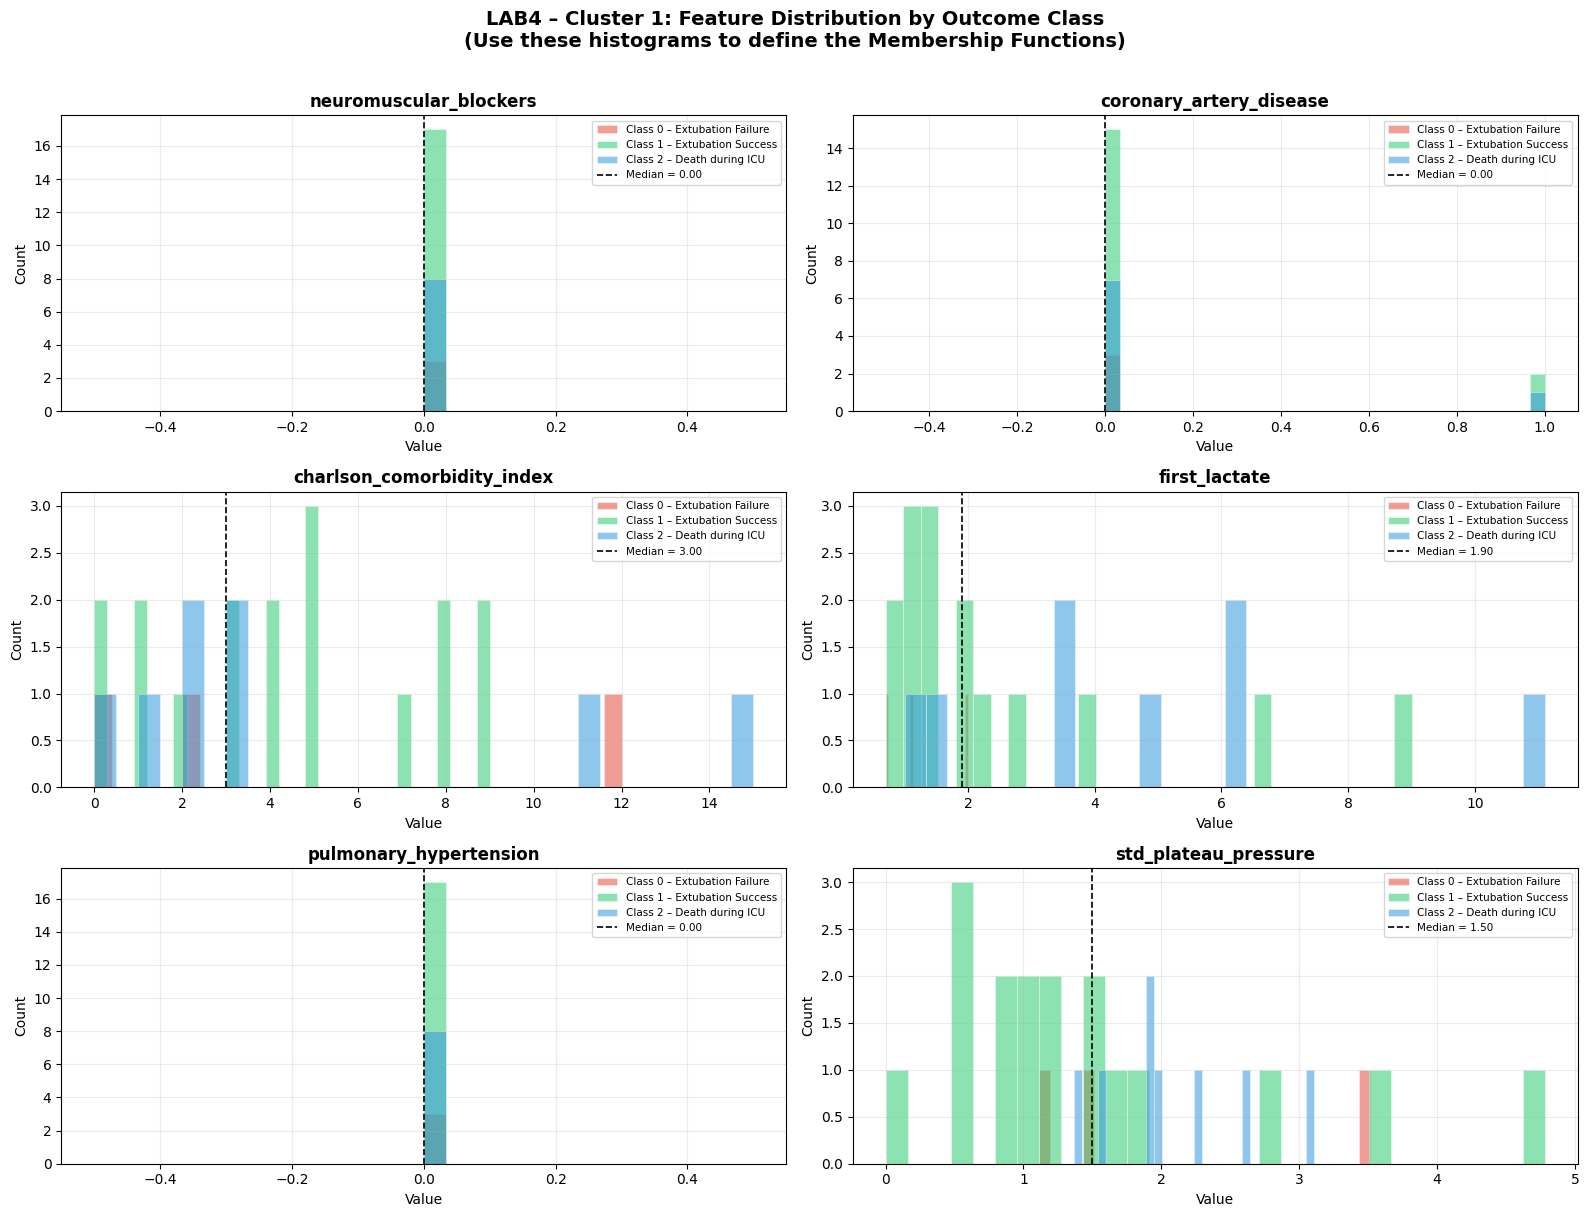

Histograms saved.


In [6]:
# ============================================================
# CELL 5 – Histograms for defining Membership Functions
# ============================================================

outcome_labels = {
    0: 'Extubation Failure',
    1: 'Extubation Success',
    2: 'Death during ICU'
}
outcome_colors = {
    0: '#e74c3c',   # red
    1: '#2ecc71',   # green
    2: '#3498db'    # blue
}

n_features = len(selected_features)
n_cols = 2
n_rows = (n_features + 1) // n_cols  # 4 righe x 2 colonne

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for idx, feat in enumerate(selected_features):
    ax = axes[idx]

    for outcome_val, label in outcome_labels.items():
        subset = cluster_df[cluster_df[outcome_col] == outcome_val][feat].dropna()
        ax.hist(
            subset,
            bins=30,
            alpha=0.55,
            color=outcome_colors[outcome_val],
            label=f'Class {outcome_val} – {label}',
            edgecolor='white',
            linewidth=0.5
        )

    # Linea verticale per la mediana globale
    global_median = cluster_df[feat].dropna().median()
    ax.axvline(global_median, color='black', linestyle='--',
               linewidth=1.2, label=f'Median = {global_median:.2f}')

    ax.set_title(f'{feat}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=7.5)
    ax.grid(True, alpha=0.25)

# Nascondi assi vuoti se n_features è dispari
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle(
    'LAB4 – Cluster 1: Feature Distribution by Outcome Class\n'
    '(Use these histograms to define the Membership Functions)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(output_dir / 'histograms_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Histograms saved.')


Binary features    (3): ['neuromuscular_blockers', 'coronary_artery_disease', 'pulmonary_hypertension']
Continuous features (3): ['charlson_comorbidity_index', 'first_lactate', 'std_plateau_pressure']


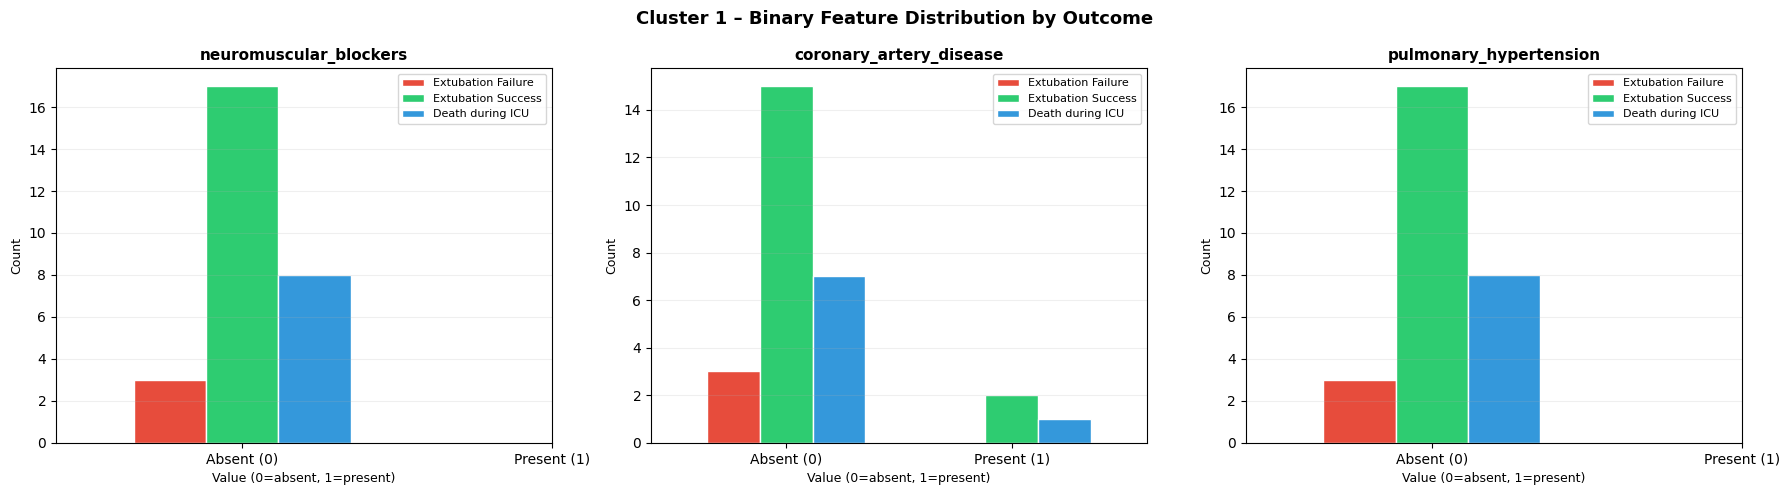

Binary histograms saved.


In [7]:
# ============================================================
# CELL 6 – Binary feature histograms
# ============================================================

# Auto-detect binary features on the COMPLETE dataset (LAB4 spec)
binary_features    = [f for f in selected_features
                      if X_full_imputed[f].dropna().isin([0, 1]).all()]
continuous_features = [f for f in selected_features
                       if f not in binary_features]

print(f'Binary features    ({len(binary_features)}): {binary_features}')
print(f'Continuous features ({len(continuous_features)}): {continuous_features}')

if binary_features:
    n_bin = len(binary_features)
    fig, axes = plt.subplots(1, n_bin, figsize=(6 * n_bin, 5))
    if n_bin == 1:
        axes = [axes]

    outcome_labels = {
        0: 'Extubation Failure',
        1: 'Extubation Success',
        2: 'Death during ICU'
    }
    colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

    for idx, feat in enumerate(binary_features):
        ax = axes[idx]
        ct = pd.crosstab(cluster_df[feat], cluster_df[outcome_col])
        ct.plot(kind='bar', ax=ax, color=[colors_class[c] for c in ct.columns],
                edgecolor='white', width=0.7)
        ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Value (0=absent, 1=present)', fontsize=9)
        ax.set_ylabel('Count', fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Absent (0)', 'Present (1)'], rotation=0)
        ax.legend([outcome_labels[c] for c in ct.columns], fontsize=8)
        ax.grid(True, alpha=0.2, axis='y')

    fig.suptitle('Cluster 1 – Binary Feature Distribution by Outcome',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'binary_histograms_cluster1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Binary histograms saved.')
else:
    print('No binary features detected.')


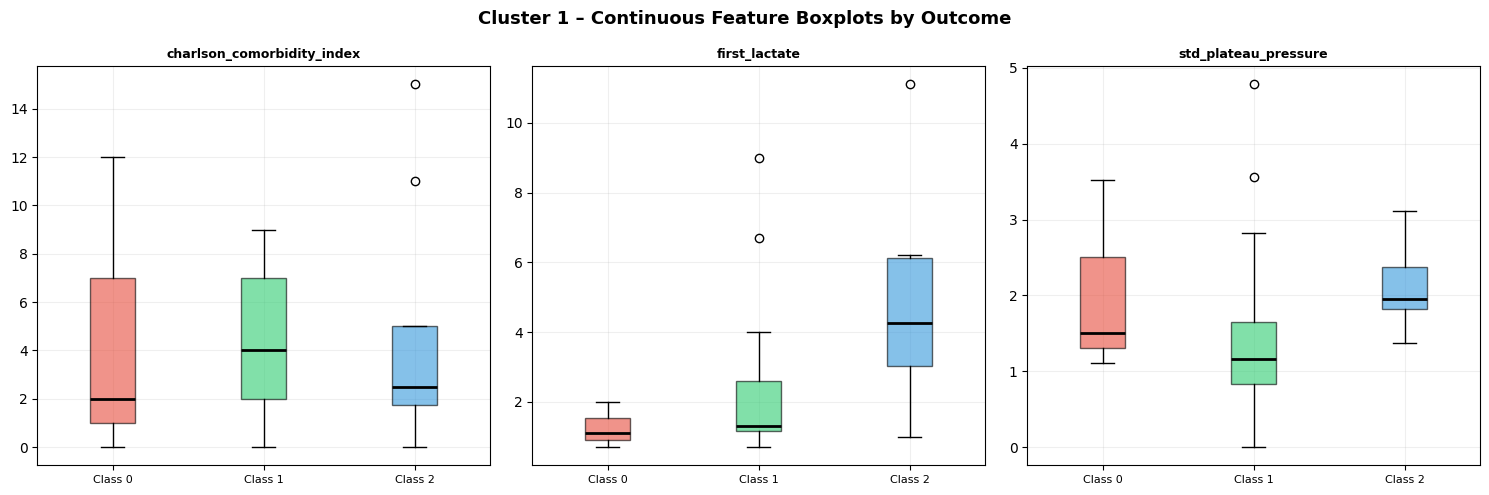

Boxplots saved.


In [8]:
# ============================================================
# CELL 7 – Boxplots for visual class comparison
# ============================================================

outcome_labels = {
    0: 'Extubation Failure',
    1: 'Extubation Success',
    2: 'Death during ICU'
}
colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

if continuous_features:
    n_cont = len(continuous_features)
    n_cols = min(5, n_cont)
    n_rows = (n_cont + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for idx, feat in enumerate(continuous_features):
        ax = axes[idx]
        data_by_class = [
            cluster_df[cluster_df[outcome_col] == c][feat].dropna().values
            for c in [0, 1, 2]
        ]
        bp = ax.boxplot(data_by_class, patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        for patch, c in zip(bp['boxes'], [0, 1, 2]):
            patch.set_facecolor(colors_class[c])
            patch.set_alpha(0.6)
        ax.set_xticks([1, 2, 3])
        ax.set_xticklabels([f'Class {c}' for c in [0, 1, 2]], fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight='bold')
        ax.grid(True, alpha=0.2)

    for idx in range(n_cont, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Cluster 1 – Continuous Feature Boxplots by Outcome',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'boxplots_cluster1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Boxplots saved.')


In [9]:
# ============================================================
# CELL 8 – Data-driven fuzzy variable and MF definitions
# ============================================================

import skfuzzy.control as ctrl
import skfuzzy as fuzz

fuzzy_inputs   = {}
feature_bounds = {}   # (lo, hi) used for clipping in inference

for feat in selected_features:
    data = X_full_imputed[feat]   # MFs designed on the complete dataset (LAB4 spec)

    if feat in binary_features:
        u = np.linspace(0, 1, 200)
        var = ctrl.Antecedent(u, feat)
        var['absent']  = fuzz.sigmf(u, 0.3, -20)
        var['present'] = fuzz.sigmf(u, 0.7,  20)
        feature_bounds[feat] = (0.0, 1.0)
    else:
        lo, hi = float(data.min()), float(data.max())
        if hi == lo:
            hi = lo + 1.0
        u  = np.linspace(lo, hi, 200)
        q1 = float(data.quantile(0.25))
        q2 = float(data.quantile(0.50))
        q3 = float(data.quantile(0.75))
        var = ctrl.Antecedent(u, feat)
        var['low']    = fuzz.trapmf(u, [lo, lo, q1, q2])
        var['medium'] = fuzz.trimf(u,  [q1, q2, q3])
        var['high']   = fuzz.trapmf(u, [q2, q3, hi, hi])
        feature_bounds[feat] = (lo, hi)

    fuzzy_inputs[feat] = var

# Output: clinical risk [0–100]
u_risk = np.linspace(0, 100, 200)
clinical_risk = ctrl.Consequent(u_risk, 'clinical_risk')
clinical_risk['low']    = fuzz.trapmf(u_risk, [0,  0,  20, 35])
clinical_risk['medium'] = fuzz.trimf(u_risk,  [25, 50, 75])
clinical_risk['high']   = fuzz.trapmf(u_risk, [65, 80, 100, 100])

print(f'Fuzzy variables built for {len(fuzzy_inputs)} features:')
for feat, var in fuzzy_inputs.items():
    lo, hi = feature_bounds[feat]
    terms  = list(var.terms.keys())
    print(f'  {feat}: [{lo:.2f}, {hi:.2f}]  terms={terms}')


Fuzzy variables built for 6 features:
  neuromuscular_blockers: [0.00, 1.00]  terms=['absent', 'present']
  coronary_artery_disease: [0.00, 1.00]  terms=['absent', 'present']
  charlson_comorbidity_index: [0.00, 19.00]  terms=['low', 'medium', 'high']
  first_lactate: [0.40, 26.00]  terms=['low', 'medium', 'high']
  pulmonary_hypertension: [0.00, 1.00]  terms=['absent', 'present']
  std_plateau_pressure: [0.00, 40.86]  terms=['low', 'medium', 'high']


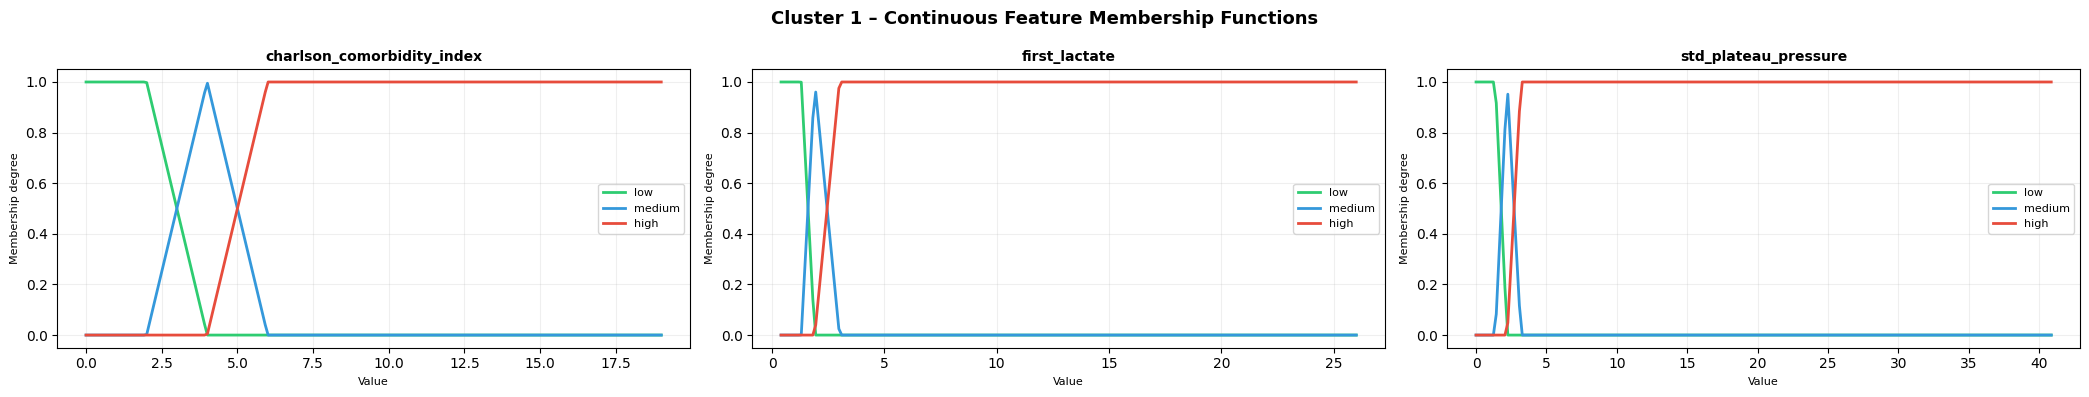

Continuous MF plot saved.


In [10]:
# ============================================================
# CELL 9 – Membership Function visualisation: continuous features
# ============================================================

if continuous_features:
    n = len(continuous_features)
    n_cols = min(3, n)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()
    colors_mf = ['#2ecc71', '#3498db', '#e74c3c']

    for idx, feat in enumerate(continuous_features):
        ax  = axes[idx]
        var = fuzzy_inputs[feat]
        for i, (term_name, _) in enumerate(var.terms.items()):
            ax.plot(var.universe, var[term_name].mf,
                    color=colors_mf[i % len(colors_mf)],
                    linewidth=2, label=term_name)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=8)
        ax.set_ylabel('Membership degree', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.set_ylim(-0.05, 1.05)

    for idx in range(n, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Cluster 1 – Continuous Feature Membership Functions',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'MF_continuous_cluster1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Continuous MF plot saved.')


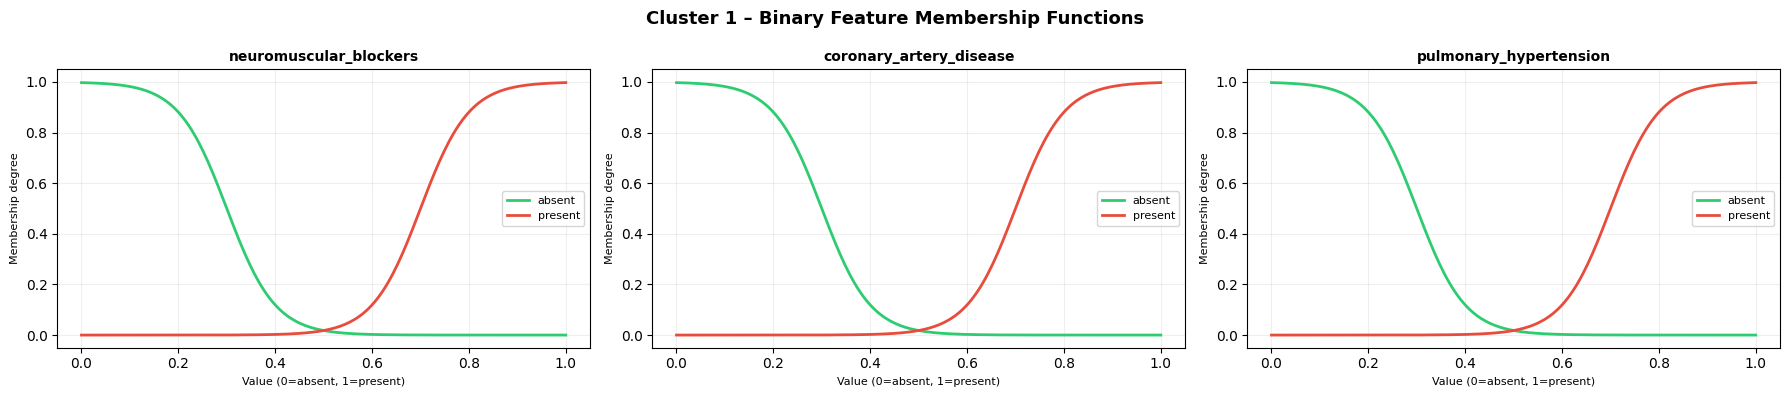

Binary MF plot saved.


In [11]:
# ============================================================
# CELL 10 – Membership Function visualisation: binary features
# ============================================================

if binary_features:
    n_bin = len(binary_features)
    fig, axes = plt.subplots(1, n_bin, figsize=(6 * n_bin, 4))
    if n_bin == 1:
        axes = [axes]
    colors_bin = ['#2ecc71', '#e74c3c']

    for idx, feat in enumerate(binary_features):
        ax  = axes[idx]
        var = fuzzy_inputs[feat]
        for i, (term_name, _) in enumerate(var.terms.items()):
            ax.plot(var.universe, var[term_name].mf,
                    color=colors_bin[i % 2], linewidth=2, label=term_name)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Value (0=absent, 1=present)', fontsize=8)
        ax.set_ylabel('Membership degree', fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.set_ylim(-0.05, 1.05)

    fig.suptitle('Cluster 1 – Binary Feature Membership Functions',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(output_dir / 'MF_binary_cluster1.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Binary MF plot saved.')
else:
    print('No binary features to plot.')


In [12]:
# ============================================================
# CELL 11 – MF summary
# ============================================================

print('=' * 65)
print('  MEMBERSHIP FUNCTIONS SUMMARY – CLUSTER 1')
print('=' * 65)

for feat, var in fuzzy_inputs.items():
    terms = list(var.terms.keys())
    lo, hi = feature_bounds[feat]
    ftype = 'binary' if feat in binary_features else 'continuous'
    print(f'  {feat}')
    print(f'    type={ftype}  range=[{lo:.2f}, {hi:.2f}]  terms={terms}')


  MEMBERSHIP FUNCTIONS SUMMARY – CLUSTER 1
  neuromuscular_blockers
    type=binary  range=[0.00, 1.00]  terms=['absent', 'present']
  coronary_artery_disease
    type=binary  range=[0.00, 1.00]  terms=['absent', 'present']
  charlson_comorbidity_index
    type=continuous  range=[0.00, 19.00]  terms=['low', 'medium', 'high']
  first_lactate
    type=continuous  range=[0.40, 26.00]  terms=['low', 'medium', 'high']
  pulmonary_hypertension
    type=binary  range=[0.00, 1.00]  terms=['absent', 'present']
  std_plateau_pressure
    type=continuous  range=[0.00, 40.86]  terms=['low', 'medium', 'high']


In [13]:
# ============================================================
# CELL 12 – Preparazione dati per il clustering
# ============================================================

from sklearn.impute import SimpleImputer

# Seleziona solo le feature scelte dall'ACO per il Cluster 1
X_cluster1 = cluster_df[selected_features].copy()

# Imputa i valori mancanti con la mediana
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_cluster1)
X_imputed = pd.DataFrame(X_imputed, columns=selected_features,
                          index=cluster_df.index)

print(f"NaN prima dell'imputazione : {X_cluster1.isna().sum().sum()}")
print(f"NaN dopo  l'imputazione   : X_imputed.isna().sum().sum()")

# Normalizzazione Min-Max sull'intero cluster
scaler_c1 = MinMaxScaler()
X_scaled_vals = scaler_c1.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled_vals,
                         columns=selected_features,
                         index=cluster_df.index)

# Aggiungi la colonna outcome per lo split successivo
X_scaled[outcome_col] = cluster_df[outcome_col].values

print(f"\n Dati pronti per il clustering!")
print(f"   → Shape matrice normalizzata : {X_scaled.shape}")
print(f"   → Range valori               : [{X_scaled[selected_features].min().min():.3f}"
      f", {X_scaled[selected_features].max().max():.3f}]")
print(f"\n Distribuzione outcome nel Cluster 1:")
display(X_scaled[outcome_col].value_counts().sort_index().rename({
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}))


NaN prima dell'imputazione : 2
NaN dopo  l'imputazione   : X_imputed.isna().sum().sum()

 Dati pronti per il clustering!
   → Shape matrice normalizzata : (28, 7)
   → Range valori               : [0.000, 1.000]

 Distribuzione outcome nel Cluster 1:


outcome
0 – Extubation Failure     3
1 – Extubation Success    17
2 – Death during ICU       8
Name: count, dtype: int64

Classe 0: 3 soggetti
Classe 1: 17 soggetti
Classe 2: 8 soggetti


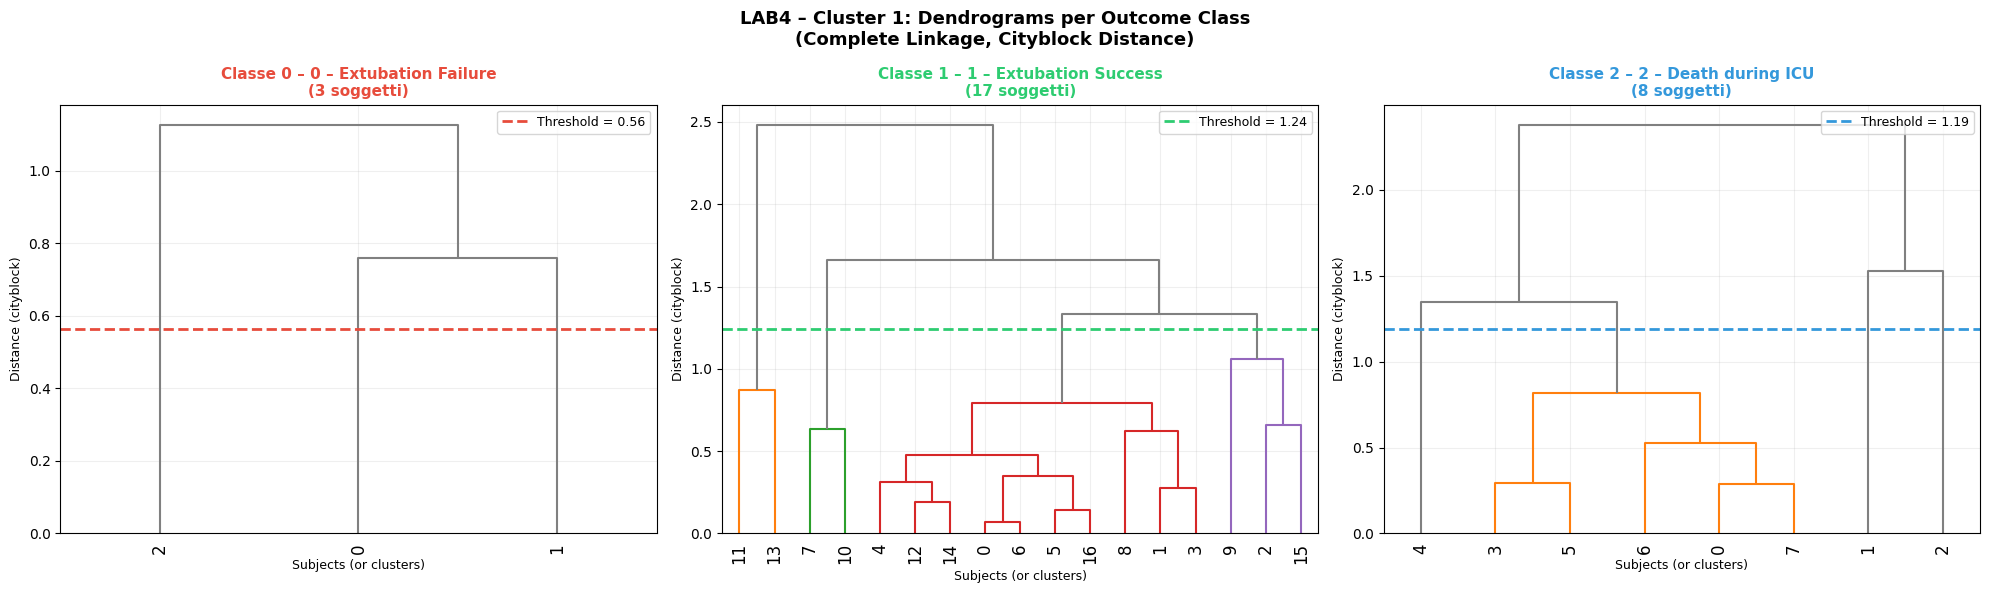

Dendrograms saved.


In [14]:
# ============================================================
# CELL 13 – Split by outcome and hierarchical clustering
#            Metodo: complete linkage, metrica: cityblock
# ============================================================

# --- Split by outcome class ---
classes = {
    0: '0 – Extubation Failure',
    1: '1 – Extubation Success',
    2: '2 – Death during ICU'
}

data_by_class = {}
for c in [0, 1, 2]:
    mask = X_scaled[outcome_col] == c
    data_by_class[c] = X_scaled[mask][selected_features].values
    print(f"Classe {c}: {data_by_class[c].shape[0]} soggetti")

# --- Clustering gerarchico per ogni classe ---
linkage_matrices = {}
n_cols_dend = 3
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}

for c in [0, 1, 2]:
    X_c = data_by_class[c]
    ax  = axes[c]

    # Linkage: complete + citybloc
    Z = linkage(X_c, method='complete', metric='cityblock')
    linkage_matrices[c] = Z

    threshold = 0.5 * max(Z[:, 2])

    dendrogram(
        Z,
        ax=ax,
        truncate_mode='lastp',
        p=20,
        show_leaf_counts=True,
        leaf_rotation=90,
        color_threshold=threshold,
        above_threshold_color='grey'
    )

    ax.axhline(
        y=threshold,
        color=colors_class[c],
        linestyle='--',
        linewidth=2,
        label=f'Threshold = {threshold:.2f}'
    )

    ax.set_title(
        f'Classe {c} – {classes[c]}\n({X_c.shape[0]} soggetti)',
        fontsize=11, fontweight='bold',
        color=colors_class[c]
    )
    ax.set_xlabel('Subjects (or clusters)', fontsize=9)
    ax.set_ylabel('Distance (cityblock)', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)

fig.suptitle(
    'LAB4 – Cluster 1: Dendrograms per Outcome Class\n'
    '(Complete Linkage, Cityblock Distance)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(output_dir / 'dendrograms_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dendrograms saved.')


In [15]:
# ============================================================
# CELL 14 – Taglio dendrogrammi e calcolo centroidi
# ============================================================

# Numero di cluster per classe (puoi modificarlo dopo aver
# osservato i dendrogrammi)
n_clusters_per_class = {
    0: 2,   # Extubation Failure  (46 soggetti  → 2 cluster)
    1: 3,   # Extubation Success  (136 soggetti → 3 cluster)
    2: 3,   # Death during ICU    (110 soggetti → 3 cluster)
}

cluster_labels  = {}
centroids_norm  = {}   # centroidi nello spazio normalizzato
centroids_real  = {}   # centroidi nello spazio originale

print("=" * 65)
print("  CENTROIDI PER CLASSE (spazio normalizzato e reale)")
print("=" * 65)

for c in [0, 1, 2]:
    X_c = data_by_class[c]
    Z   = linkage_matrices[c]
    n_k = n_clusters_per_class[c]

    # Taglia il dendrogramma
    labels = fcluster(Z, n_k, criterion='maxclust')
    cluster_labels[c] = labels

    # Calcola centroidi normalizzati
    cents_norm = []
    for k in range(1, n_k + 1):
        mask   = labels == k
        if mask.sum() > 0:
            centroid = X_c[mask].mean(axis=0)
            cents_norm.append(centroid)

    cents_norm = np.array(cents_norm)
    centroids_norm[c] = cents_norm

    # Denormalizza i centroidi → spazio originale
    cents_real = scaler_c1.inverse_transform(cents_norm)
    cents_real = pd.DataFrame(cents_real,
                               columns=selected_features,
                               index=[f'C{c}_k{k+1}' for k in range(len(cents_norm))])
    centroids_real[c] = cents_real

    print(f"\n Classe {c} – {classes[c]}")
    print(f"   Soggetti: {X_c.shape[0]}  |  Cluster: {n_k}")
    for k in range(1, n_k + 1):
        n_sogg = (labels == k).sum()
        print(f"   → Cluster {k}: {n_sogg} soggetti")
    print(f"\n   Centroidi (spazio reale):")
    display(cents_real.round(3))

print("\n Centroidi calcolati e denormalizzati")



  CENTROIDI PER CLASSE (spazio normalizzato e reale)

 Classe 0 – 0 – Extubation Failure
   Soggetti: 3  |  Cluster: 2
   → Cluster 1: 3 soggetti
   → Cluster 2: 0 soggetti

   Centroidi (spazio reale):


,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_plateau_pressure
C0_k1,0.0,0.0,4.667,1.267,0.0,2.042



 Classe 1 – 1 – Extubation Success
   Soggetti: 17  |  Cluster: 3
   → Cluster 1: 2 soggetti
   → Cluster 2: 2 soggetti
   → Cluster 3: 13 soggetti

   Centroidi (spazio reale):


,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_plateau_pressure
C1_k1,0.0,1.0,6.500,1.350,0.0,2.528
C1_k2,0.0,0.0,5.500,1.150,0.0,3.804
C1_k3,0.0,0.0,3.846,2.785,0.0,0.985



 Classe 2 – 2 – Death during ICU
   Soggetti: 8  |  Cluster: 3
   → Cluster 1: 6 soggetti
   → Cluster 2: 1 soggetti
   → Cluster 3: 1 soggetti

   Centroidi (spazio reale):


,neuromuscular_blockers,coronary_artery_disease,charlson_comorbidity_index,first_lactate,pulmonary_hypertension,std_plateau_pressure
C2_k1,0.0,0.0,1.833,4.467,0.0,2.040
C2_k2,0.0,0.0,15.000,6.200,0.0,1.907
C2_k3,0.0,1.0,11.000,5.000,0.0,2.601



 Centroidi calcolati e denormalizzati


In [16]:
# ============================================================
# CELL 15 – Automatic fuzzy rule generation from centroids
# ============================================================

outcome_to_risk = {
    0: 'medium',
    1: 'low',
    2: 'high',
}

def get_best_mf(value, fuzzy_var):
    best_term, best_mu = None, -1.0
    for term_name in fuzzy_var.terms:
        mu = fuzz.interp_membership(
            fuzzy_var.universe, fuzzy_var[term_name].mf, value)
        if mu > best_mu:
            best_mu, best_term = mu, term_name
    return best_term, best_mu

print('=' * 70)
print('  AUTO RULE GENERATION FROM CENTROIDS')
print('=' * 70)

auto_rules_data = []

for c in [0, 1, 2]:
    cents = centroids_real[c]
    print(f"\n{'─'*70}")
    print(f"  Class {c} → clinical_risk = '{outcome_to_risk[c]}'")

    for row_name, row in cents.iterrows():
        rule_dict = {}
        for feat in selected_features:
            best_term, _ = get_best_mf(row[feat], fuzzy_inputs[feat])
            rule_dict[feat] = best_term
        rule_dict.update({
            'clinical_risk': outcome_to_risk[c],
            'source': 'auto', 'class': c, 'centroid_id': row_name,
        })
        auto_rules_data.append(rule_dict)

        antecedents = ' AND '.join(
            [f"{f}='{rule_dict[f]}'" for f in selected_features])
        print(f"  Rule {len(auto_rules_data)} ({row_name}): IF {antecedents}")
        print(f"    THEN clinical_risk='{outcome_to_risk[c]}'")

print(f'\nTotal auto rules from centroids: {len(auto_rules_data)}')


  AUTO RULE GENERATION FROM CENTROIDS

──────────────────────────────────────────────────────────────────────
  Class 0 → clinical_risk = 'medium'
  Rule 1 (C0_k1): IF neuromuscular_blockers='absent' AND coronary_artery_disease='absent' AND charlson_comorbidity_index='medium' AND first_lactate='low' AND pulmonary_hypertension='absent' AND std_plateau_pressure='medium'
    THEN clinical_risk='medium'

──────────────────────────────────────────────────────────────────────
  Class 1 → clinical_risk = 'low'
  Rule 2 (C1_k1): IF neuromuscular_blockers='absent' AND coronary_artery_disease='present' AND charlson_comorbidity_index='high' AND first_lactate='low' AND pulmonary_hypertension='absent' AND std_plateau_pressure='medium'
    THEN clinical_risk='low'
  Rule 3 (C1_k2): IF neuromuscular_blockers='absent' AND coronary_artery_disease='absent' AND charlson_comorbidity_index='high' AND first_lactate='low' AND pulmonary_hypertension='absent' AND std_plateau_pressure='high'
    THEN clinical_r

In [17]:
# ============================================================
# CELL 16 – Pairwise rules + FIS construction
# ============================================================

# Build rules: one per centroid (all features in AND)
# + pairwise rules for broader coverage.

all_rules_data = list(auto_rules_data)

# Add pairwise rules for each centroid (every pair of consecutive features)
import itertools
for rule_d in auto_rules_data:
    risk = rule_d['clinical_risk']
    feats = selected_features
    for fa, fb in itertools.combinations(feats[:6], 2):   # top-6 features, all pairs
        pw_dict = {
            fa: rule_d[fa],
            fb: rule_d[fb],
            'clinical_risk': risk,
            'source': 'pairwise',
            'class': rule_d['class'],
            'centroid_id': rule_d['centroid_id'] + '_pw',
        }
        all_rules_data.append(pw_dict)

print(f'Rules: {len(auto_rules_data)} centroid + {len(all_rules_data) - len(auto_rules_data)} pairwise = {len(all_rules_data)} total')

# Build skfuzzy Rule objects -------------------------------------------------
def build_antecedent(rule_d, feats):
    ant = None
    for f in feats:
        if f not in rule_d:
            continue
        term  = rule_d[f]
        piece = fuzzy_inputs[f][term]
        ant   = piece if ant is None else ant & piece
    return ant

fis_rules = []
seen_rules = set()

for rd in all_rules_data:
    feats_in_rule = [f for f in selected_features if f in rd and rd[f] is not None]
    if not feats_in_rule:
        continue
    key = tuple(sorted((f, rd[f]) for f in feats_in_rule)) + (rd['clinical_risk'],)
    if key in seen_rules:
        continue
    seen_rules.add(key)
    ant = build_antecedent(rd, feats_in_rule)
    if ant is not None:
        try:
            fis_rules.append(ctrl.Rule(ant, clinical_risk[rd['clinical_risk']]))
        except Exception:
            pass

print(f'Unique skfuzzy rules built: {len(fis_rules)}')

# Build FIS
fis_ctrl  = ctrl.ControlSystem(fis_rules)
fis_sim   = ctrl.ControlSystemSimulation(fis_ctrl)
print('FIS constructed successfully.')


Rules: 7 centroid + 105 pairwise = 112 total
Unique skfuzzy rules built: 83


FIS constructed successfully.


In [18]:
# ============================================================
# CELL 17 – FIS application to Cluster 1
# ============================================================

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

X_real = X_imputed.copy()
X_real[outcome_col] = cluster_df[outcome_col].values

results   = []
n_fallback = 0

print('Applying FIS to Cluster 1...')

for i, (idx, row) in enumerate(tqdm(X_real.iterrows(),
                                     total=len(X_real),
                                     desc='FIS Cluster 1')):
    try:
        for feat in selected_features:
            lo, hi = feature_bounds[feat]
            fis_sim.input[feat] = float(np.clip(row[feat], lo, hi))
        fis_sim.compute()
        score = float(fis_sim.output['clinical_risk'])
    except Exception:
        n_fallback += 1
        # Fallback: nearest centroid in normalised space
        row_norm = scaler_c1.transform([row[selected_features].values])[0]
        min_dist = np.inf
        score    = 50.0
        for c in [0, 1, 2]:
            for cent in centroids_norm[c]:
                d = np.linalg.norm(row_norm - cent)
                if d < min_dist:
                    min_dist = d
                    score    = {'low': 15, 'medium': 50, 'high': 85}[outcome_to_risk[c]]

    results.append({'idx': idx, 'outcome': row[outcome_col], 'clinical_risk': score})

results_df = pd.DataFrame(results).set_index('idx')
results_df_v2 = results_df.copy()
print(f'\nFIS complete: {len(results_df)} subjects, {n_fallback} fallbacks '
      f'({n_fallback/len(results_df)*100:.1f}%)')
print(f'Score stats: mean={results_df["clinical_risk"].mean():.1f}, '
      f'std={results_df["clinical_risk"].std():.1f}')


Applying FIS to Cluster 1...


FIS Cluster 1:   0%|          | 0/28 [00:00<?, ?it/s]


FIS complete: 28 subjects, 0 fallbacks (0.0%)
Score stats: mean=50.0, std=0.0


In [19]:
# ============================================================
# CELL 18  – Classificazione e Valutazione Performance
#               con grid search soglie ottimali
# ============================================================

from sklearn.metrics import (accuracy_score,
                              balanced_accuracy_score,
                              classification_report,
                              confusion_matrix)

print(" Grid search soglie ottimali...")

best_acc      = 0
best_bal_acc  = 0
best_t1, best_t2 = 40, 60
results_grid  = []

for t1 in range(15, 65, 5):
    for t2 in range(t1 + 10, 95, 5):

        def s2c(s, _t1=t1, _t2=t2):
            if s < _t1:   return 1
            elif s < _t2: return 0
            else:          return 2

        y_p     = results_df_v2['clinical_risk'].apply(s2c).values
        y_t     = results_df_v2['outcome'].values
        acc_t   = accuracy_score(y_t, y_p)
        bal_t   = balanced_accuracy_score(y_t, y_p)

        results_grid.append({
            't1': t1, 't2': t2,
            'accuracy': acc_t,
            'balanced_accuracy': bal_t
        })

        if bal_t > best_bal_acc:
            best_bal_acc = bal_t
            best_acc     = acc_t
            best_t1, best_t2 = t1, t2

grid_df = pd.DataFrame(results_grid).sort_values(
    'balanced_accuracy', ascending=False
)

print(f"\n Soglie ottimali trovate:")
print(f"   → Soglia Low/Medium  : {best_t1}")
print(f"   → Soglia Medium/High : {best_t2}")
print(f"   → Accuracy           : {best_acc*100:.2f}%")
print(f"   → Balanced Accuracy  : {best_bal_acc*100:.2f}%")

print(f"\n Top 5 combinazioni soglie:")
display(grid_df.head(5).round(4))

# --- Classificazione finale ---
def score_to_class_final(s):
    if s < best_t1:   return 1
    elif s < best_t2: return 0
    else:              return 2

results_df_v2['predicted_class'] = results_df_v2[
    'clinical_risk'
].apply(score_to_class_final)

y_true_v2 = results_df_v2['outcome'].values
y_pred_v2 = results_df_v2['predicted_class'].values

# --- Metriche finali ---
acc_f     = accuracy_score(y_true_v2, y_pred_v2)
bal_acc_f = balanced_accuracy_score(y_true_v2, y_pred_v2)

print(f"\n{'='*65}")
print(f"  VALUTAZIONE PERFORMANCE FIS v2 – CLUSTER 1")
print(f"{'='*65}")
print(f"\n   Accuracy          : {acc_f:.4f}  ({acc_f*100:.2f}%)")
print(f"   Balanced Accuracy : {bal_acc_f:.4f}  ({bal_acc_f*100:.2f}%)")
print(f"\n{'─'*65}")
print("  Classification Report:")
print(f"{'─'*65}")
print(classification_report(
    y_true_v2, y_pred_v2,
    target_names=[
        '0–Extubation Failure',
        '1–Extubation Success',
        '2–Death during ICU'
    ],
    digits=4
))

cm_v2 = confusion_matrix(y_true_v2, y_pred_v2, labels=[0, 1, 2])
cm_df_v2 = pd.DataFrame(
    cm_v2,
    index   = ['True: Failure', 'True: Success', 'True: Death'],
    columns = ['Pred: Failure', 'Pred: Success', 'Pred: Death']
)
print(f"{'─'*65}")
print("  Confusion Matrix:")
print(f"{'─'*65}")
display(cm_df_v2)

# --- Percentuale classificati per classe ---
labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}

print(f"\n{'─'*65}")
print("  Distribuzione classificazione per outcome class:")
print(f"{'─'*65}")
for c in [0, 1, 2]:
    mask_c  = results_df_v2['outcome'] == c
    n_tot_c = mask_c.sum()

    # Check if knn_fallback column exists
    if 'knn_fallback' in results_df_v2.columns:
        n_fis_c = (mask_c & ~results_df_v2['knn_fallback']).sum()
        n_knn_c = (mask_c &  results_df_v2['knn_fallback']).sum()
        print(f"\n  Classe {c} ({labels_class[c]}):")
        print(f"   → FIS classificati : {n_fis_c} "
              f"({n_fis_c/n_tot_c*100:.1f}%)")
        print(f"   → KNN fallback     : {n_knn_c} "
              f"({n_knn_c/n_tot_c*100:.1f}%)")
        print(f"   → Totale           : {n_tot_c} (100%)")
    else:
        n_class_c = mask_c.sum()
        print(f"\n  Classe {c} ({labels_class[c]}):")
        print(f"   → Classificati     : {n_class_c} (100%)")


 Grid search soglie ottimali...

 Soglie ottimali trovate:
   → Soglia Low/Medium  : 15
   → Soglia Medium/High : 50
   → Accuracy           : 25.00%
   → Balanced Accuracy  : 50.00%

 Top 5 combinazioni soglie:


,t1,t2,accuracy,balanced_accuracy
5,15,50,0.25,0.5
41,30,50,0.25,0.5
51,35,50,0.25,0.5
18,20,50,0.25,0.5
30,25,50,0.25,0.5



  VALUTAZIONE PERFORMANCE FIS v2 – CLUSTER 1

   Accuracy          : 0.2500  (25.00%)
   Balanced Accuracy : 0.5000  (50.00%)

─────────────────────────────────────────────────────────────────
  Classification Report:
─────────────────────────────────────────────────────────────────
                      precision    recall  f1-score   support

0–Extubation Failure     0.1364    1.0000    0.2400         3
1–Extubation Success     0.0000    0.0000    0.0000        17
  2–Death during ICU     0.6667    0.5000    0.5714         8

            accuracy                         0.2500        28
           macro avg     0.2677    0.5000    0.2705        28
        weighted avg     0.2051    0.2500    0.1890        28

─────────────────────────────────────────────────────────────────
  Confusion Matrix:
─────────────────────────────────────────────────────────────────


,Pred: Failure,Pred: Success,Pred: Death
True: Failure,3,0,0
True: Success,15,0,2
True: Death,4,0,4



─────────────────────────────────────────────────────────────────
  Distribuzione classificazione per outcome class:
─────────────────────────────────────────────────────────────────

  Classe 0 (0–Extubation Failure):
   → Classificati     : 3 (100%)

  Classe 1 (1–Extubation Success):
   → Classificati     : 17 (100%)

  Classe 2 (2–Death during ICU):
   → Classificati     : 8 (100%)


Cluster 1 variables ready.
  → n patients : 28
   → t1         : 35
   → t2         : 50
   → Accuracy   : 25.00%


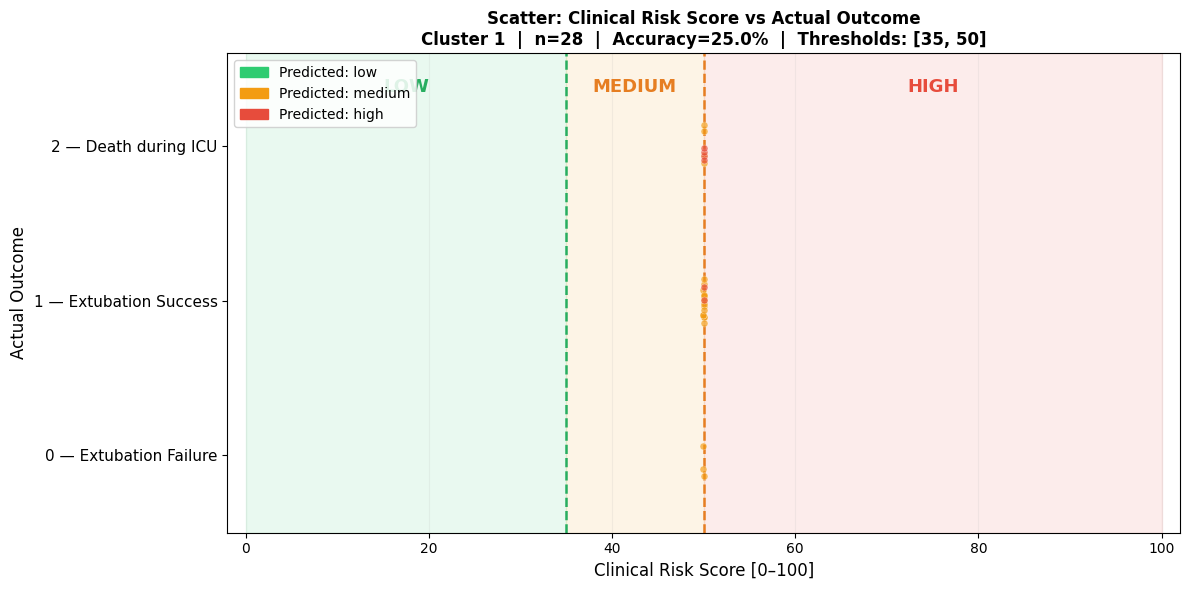

 Scatter Cluster 1 salvato in 'scatter_clinical_risk_cluster1.png'


In [20]:
# ============================================================
# CELL 19 – Cluster 1
# Clinical Risk Score vs Actual Outcome
# ============================================================

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# ── Cluster 1 variables ──
results_df_c1 = results_df_v2.copy()
best_t1_c1    = 35    # ← soglia Low/Medium  Cluster 1
best_t2_c1    = 50    # ← soglia Medium/High Cluster 1
acc_f_c1      = accuracy_score(
    results_df_c1['outcome'],
    results_df_c1['predicted_class']
)

print('Cluster 1 variables ready.')
print(f'  → n patients : {len(results_df_c1)}')
print(f"   → t1         : {best_t1_c1}")
print(f"   → t2         : {best_t2_c1}")
print(f"   → Accuracy   : {acc_f_c1*100:.2f}%")

# ── Colour map for predicted class ──
color_map = {
    0: '#f39c12',   # Predicted: medium  → arancione
    1: '#2ecc71',   # Predicted: low  → verde
    2: '#e74c3c'    # Predicted: high   → rosso
}
label_map = {
    0: 'Predicted: medium',
    1: 'Predicted: low',
    2: 'Predicted: high'
}

# ── Figura ──
fig, ax = plt.subplots(figsize=(12, 6))

# --- Background zone shading ---
ax.axvspan(0,          best_t1_c1,
           color='#2ecc71', alpha=0.10, zorder=0)
ax.axvspan(best_t1_c1, best_t2_c1,
           color='#f39c12', alpha=0.10, zorder=0)
ax.axvspan(best_t2_c1, 100,
           color='#e74c3c', alpha=0.10, zorder=0)

# --- Threshold vertical lines ---
ax.axvline(x=best_t1_c1,
           color='#27ae60', linestyle='--',
           linewidth=1.8, zorder=1)
ax.axvline(x=best_t2_c1,
           color='#e67e22', linestyle='--',
           linewidth=1.8, zorder=1)

# --- Zone labels ---
ax.text(best_t1_c1 / 2,
        2.38, 'LOW',
        color='#27ae60', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t1_c1 + best_t2_c1) / 2,
        2.38, 'MEDIUM',
        color='#e67e22', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)
ax.text((best_t2_c1 + 100) / 2,
        2.38, 'HIGH',
        color='#e74c3c', fontsize=13,
        fontweight='bold',
        ha='center', va='center', zorder=5)

# --- Scatter by predicted class ---
np.random.seed(42)
for pred_class in [1, 0, 2]:
    mask   = (results_df_c1['predicted_class']
               == pred_class)
    subset = results_df_c1[mask].reset_index(drop=True)
    jitter = np.random.uniform(
        -0.15, 0.15, size=len(subset)
    )
    ax.scatter(
        subset['clinical_risk'],
        subset['outcome'] + jitter,
        color=color_map[pred_class],
        label=label_map[pred_class],
        alpha=0.65,
        s=25,
        edgecolors='white',
        linewidths=0.3,
        zorder=3
    )

# --- Y-axis ---
ax.set_yticks([0, 1, 2])
ax.set_yticklabels([
    '0 — Extubation Failure',
    '1 — Extubation Success',
    '2 — Death during ICU'
], fontsize=11)

# --- X-axis ---
ax.set_xlim([-2, 102])
ax.set_ylim([-0.5, 2.6])
ax.set_xlabel('Clinical Risk Score [0–100]',
              fontsize=12)
ax.set_ylabel('Actual Outcome', fontsize=12)

# --- Title ---
ax.set_title(
    f'Scatter: Clinical Risk Score vs Actual Outcome\n'
    f'Cluster 1  |  n={len(results_df_c1)}  |  '
    f'Accuracy={acc_f_c1*100:.1f}%  |  '
    f'Thresholds: [{best_t1_c1}, {best_t2_c1}]',
    fontsize=12, fontweight='bold'
)

# --- Legend ---
handles = [
    mpatches.Patch(color='#2ecc71',
                   label='Predicted: low'),
    mpatches.Patch(color='#f39c12',
                   label='Predicted: medium'),
    mpatches.Patch(color='#e74c3c',
                   label='Predicted: high'),
]
ax.legend(handles=handles, fontsize=10,
          loc='upper left', framealpha=0.85)
ax.grid(True, alpha=0.15, axis='x')

plt.tight_layout()
plt.savefig(output_dir / 'scatter_clinical_risk_cluster1.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Scatter Cluster 1 salvato in "
      "'scatter_clinical_risk_cluster1.png'")


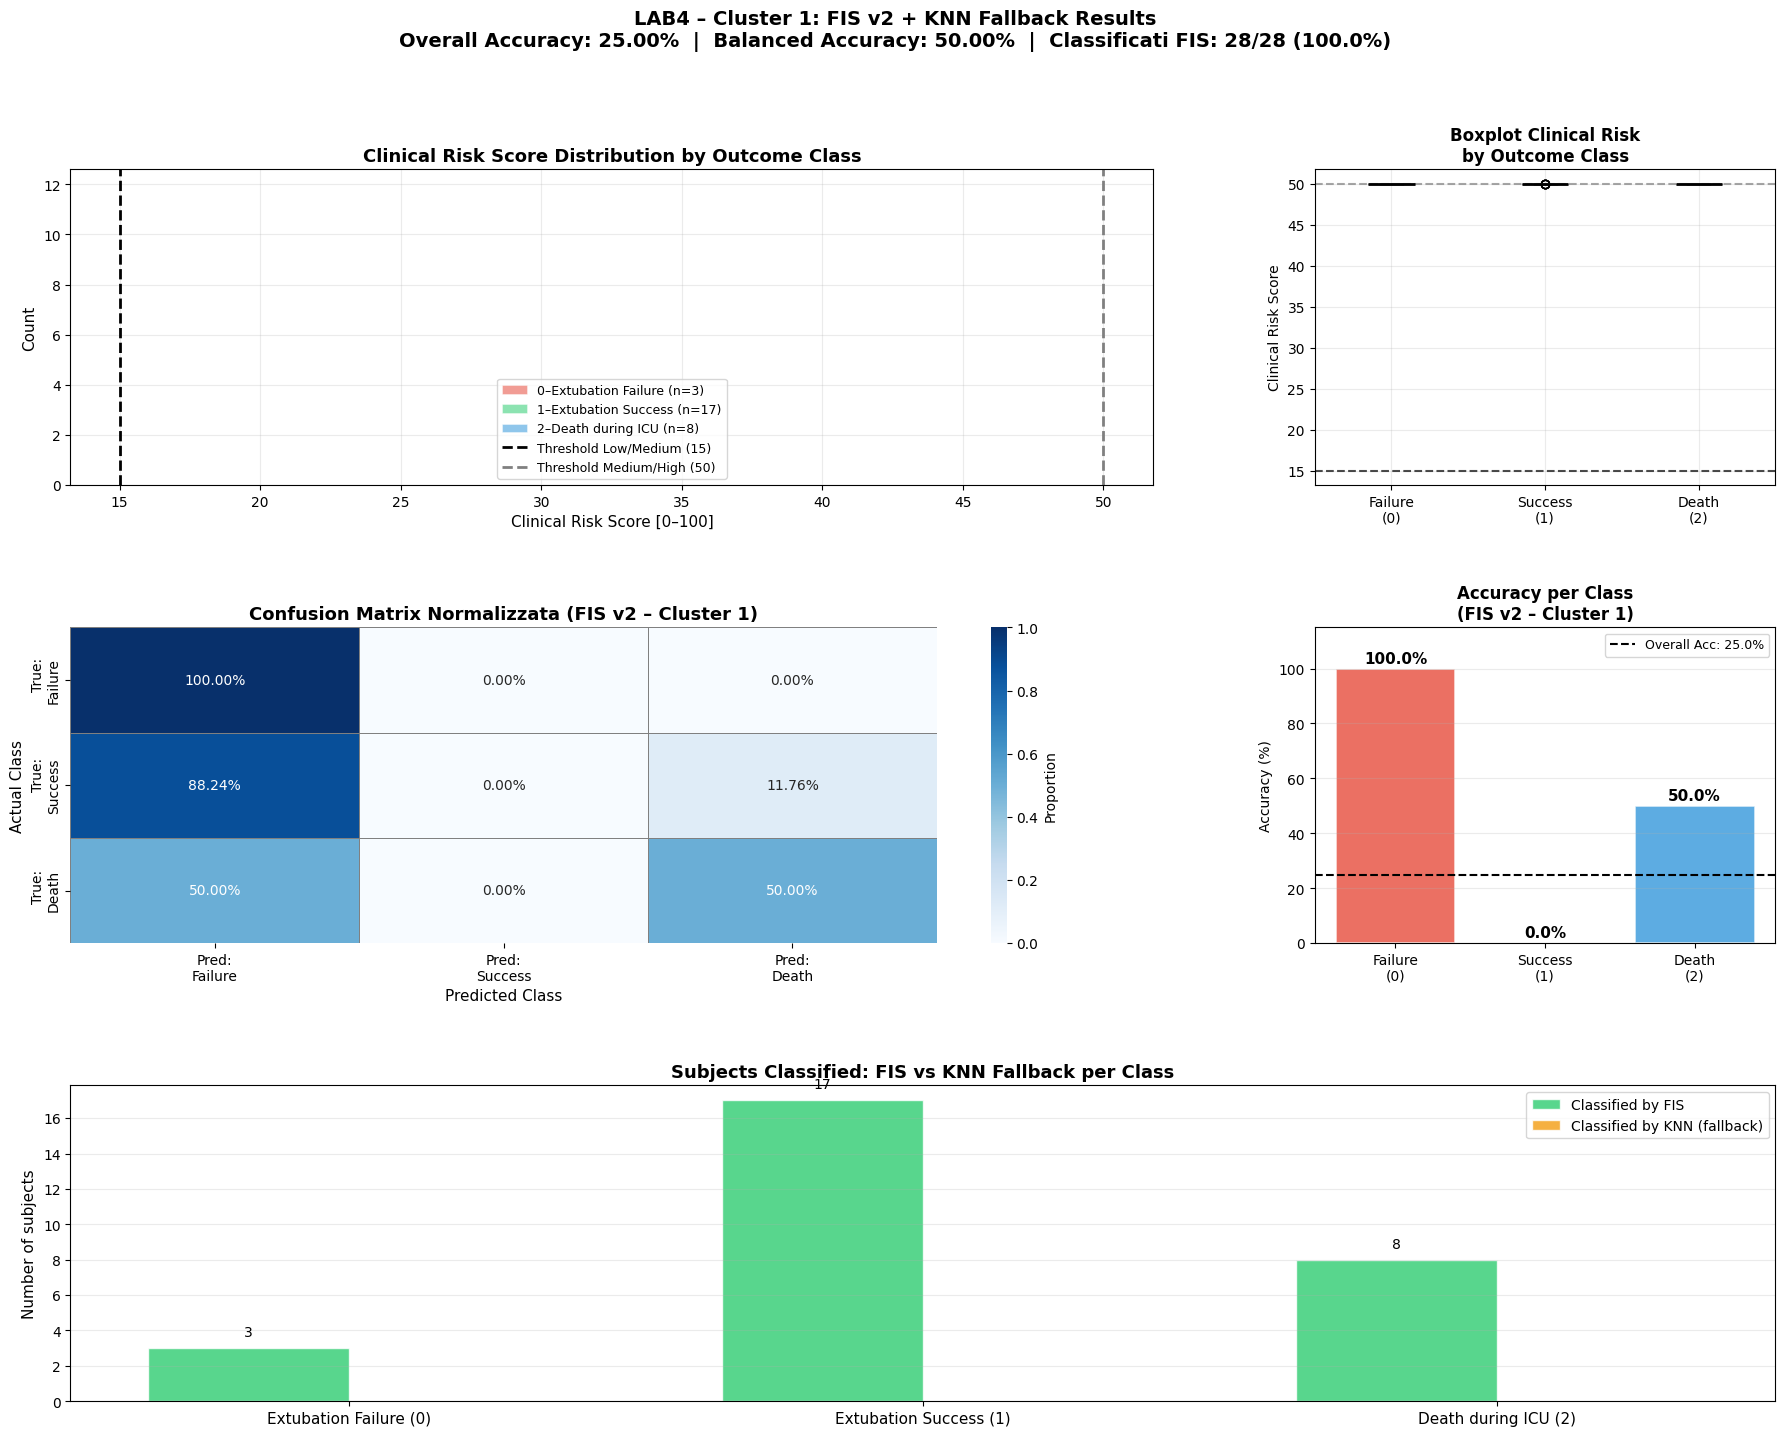

FIS results saved.


In [21]:
# ============================================================
# CELL 20 – FIS results visualisation
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

fig = plt.figure(figsize=(22, 16))
gs  = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

colors_class = {0: '#e74c3c', 1: '#2ecc71', 2: '#3498db'}
labels_class = {
    0: '0–Extubation Failure',
    1: '1–Extubation Success',
    2: '2–Death during ICU'
}

# ── Plot 1: Distribuzione score ──
ax1 = fig.add_subplot(gs[0, :2])
for c in [0, 1, 2]:
    subset = results_df_v2[results_df_v2['outcome'] == c]['clinical_risk']
    ax1.hist(subset, bins=30, alpha=0.55,
             color=colors_class[c],
             label=f'{labels_class[c]} (n={len(subset)})',
             edgecolor='white', linewidth=0.5)

ax1.axvline(x=best_t1, color='black', linestyle='--',
            linewidth=2, label=f'Threshold Low/Medium ({best_t1})')
ax1.axvline(x=best_t2, color='grey',  linestyle='--',
            linewidth=2, label=f'Threshold Medium/High ({best_t2})')
ax1.set_title('Clinical Risk Score Distribution by Outcome Class',
              fontsize=13, fontweight='bold')
ax1.set_xlabel('Clinical Risk Score [0–100]', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25)

# ── Plot 2: Boxplot ──
ax2 = fig.add_subplot(gs[0, 2])
data_box = [
    results_df_v2[results_df_v2['outcome'] == c]['clinical_risk'].values
    for c in [0, 1, 2]
]
bp = ax2.boxplot(data_box, patch_artist=True,
                  medianprops=dict(color='black', linewidth=2))
for patch, c in zip(bp['boxes'], [0, 1, 2]):
    patch.set_facecolor(colors_class[c])
    patch.set_alpha(0.7)
ax2.axhline(y=best_t1, color='black', linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.axhline(y=best_t2, color='grey',  linestyle='--',
            linewidth=1.5, alpha=0.7)
ax2.set_xticklabels(['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
                     fontsize=10)
ax2.set_title('Boxplot Clinical Risk\nby Outcome Class',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Clinical Risk Score', fontsize=10)
ax2.grid(True, alpha=0.25)

# ── Plot 3: Confusion Matrix heatmap ──
ax3 = fig.add_subplot(gs[1, :2])
cm_norm_v2 = confusion_matrix(
    y_true_v2, y_pred_v2, labels=[0, 1, 2], normalize='true'
)
sns.heatmap(
    cm_norm_v2,
    annot=True, fmt='.2%',
    cmap='Blues', ax=ax3,
    xticklabels=['Pred:\nFailure', 'Pred:\nSuccess', 'Pred:\nDeath'],
    yticklabels=['True:\nFailure', 'True:\nSuccess', 'True:\nDeath'],
    linewidths=0.5, linecolor='grey',
    cbar_kws={'label': 'Proportion'}
)
ax3.set_title('Confusion Matrix Normalizzata (FIS v2 – Cluster 1)',
              fontsize=13, fontweight='bold')
ax3.set_xlabel('Predicted Class', fontsize=11)
ax3.set_ylabel('Actual Class', fontsize=11)

# ── Plot 4: Accuracy per classe ──
ax4 = fig.add_subplot(gs[1, 2])
per_class_acc_v2 = []
for c in [0, 1, 2]:
    mask  = y_true_v2 == c
    acc_c = accuracy_score(y_true_v2[mask], y_pred_v2[mask])
    per_class_acc_v2.append(acc_c)

bars = ax4.bar(
    ['Failure\n(0)', 'Success\n(1)', 'Death\n(2)'],
    [a * 100 for a in per_class_acc_v2],
    color=[colors_class[c] for c in [0, 1, 2]],
    alpha=0.8, edgecolor='white', linewidth=1.2
)
for bar, acc_c in zip(bars, per_class_acc_v2):
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{acc_c*100:.1f}%',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )
ax4.axhline(y=acc_f * 100, color='black', linestyle='--',
            linewidth=1.5,
            label=f'Overall Acc: {acc_f*100:.1f}%')
ax4.set_title('Accuracy per Class\n(FIS v2 – Cluster 1)',
              fontsize=12, fontweight='bold')
ax4.set_ylabel('Accuracy (%)', fontsize=10)
ax4.set_ylim([0, 115])
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25, axis='y')

# ── Plot 5: FIS vs KNN classificati per classe ──
ax5 = fig.add_subplot(gs[2, :])
x     = np.arange(3)
width = 0.35

# Check if knn_fallback column exists
if 'knn_fallback' in results_df_v2.columns:
    n_fis_per_class = [
        (~results_df_v2['knn_fallback'] &
         (results_df_v2['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [
        (results_df_v2['knn_fallback'] &
         (results_df_v2['outcome'] == c)).sum()
        for c in [0, 1, 2]
    ]
else:
    # If no KNN fallback column → tutti classificati da FIS
    n_fis_per_class = [
        (results_df_v2['outcome'] == c).sum()
        for c in [0, 1, 2]
    ]
    n_knn_per_class = [0, 0, 0]

bars1 = ax5.bar(x - width/2, n_fis_per_class, width,
                label='Classified by FIS',
                color='#2ecc71', alpha=0.8,
                edgecolor='white')
bars2 = ax5.bar(x + width/2, n_knn_per_class, width,
                label='Classified by KNN (fallback)',
                color='#f39c12', alpha=0.8,
                edgecolor='white')

for bar in bars1:
    if bar.get_height() > 0:
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=10)
for bar in bars2:
    if bar.get_height() > 0:
        ax5.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontsize=10)

ax5.set_xticks(x)
ax5.set_xticklabels([
    'Extubation Failure (0)',
    'Extubation Success (1)',
    'Death during ICU (2)'
], fontsize=11)
ax5.set_title('Subjects Classified: FIS vs KNN Fallback per Class',
              fontsize=13, fontweight='bold')
ax5.set_ylabel('Number of subjects', fontsize=11)
ax5.legend(fontsize=10)
ax5.grid(True, alpha=0.25, axis='y')

# Compute totals for figure title
n_fis_tot = sum(n_fis_per_class)
n_knn_tot = sum(n_knn_per_class)
n_tot     = len(results_df_v2)

fig.suptitle(
    f'LAB4 – Cluster 1: FIS v2 + KNN Fallback Results\n'
    f'Overall Accuracy: {acc_f*100:.2f}%  |  '
    f'Balanced Accuracy: {bal_acc_f*100:.2f}%  |  '
    f'Classificati FIS: {n_fis_tot}/{n_tot} '
    f'({n_fis_tot/n_tot*100:.1f}%)',
    fontsize=14, fontweight='bold'
)

plt.savefig(output_dir / 'FIS_results_cluster1.png', dpi=150, bbox_inches='tight')
plt.show()
print('FIS results saved.')
